<a href="https://colab.research.google.com/github/adryann-olivatti/IC_cozinhas_solidarias/blob/main/notebook_renda_cozinhas_solidarias_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Renda por Organização Fornecedora (PAA - Cozinhas Solidárias)

Este notebook responde à seguinte pergunta:
**"Qual é a renda por organização fornecedora, categorizada por tipo?"**

### Fontes de Dados Utilizadas:
1. **Catálogo de Dados (JSON):** [GitHub - TriangulosTecnologia/cozsolidarias](https://github.com/TriangulosTecnologia/cozsolidarias/blob/main/public/dataset_catalogue.json)
2. **Portal de Dados:** [Cozinhas Solidárias - Dados](https://cozsolidarias.triangulos.tech/dados)
3. **Planilha de Dados CONAB:** [Google Sheets - Dados CONAB PAA 2025](https://docs.google.com/spreadsheets/d/1O_mmcnZ2QCBkA6juq_TzKYFv6KDwHsCU/edit)

## 1. Importação de Bibliotecas e Configuração Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: 'R$ {:,.2f}'.format(x))

## 2. Carregamento dos Dados da CONAB
Baixando diretamente os dados da planilha do Google Sheets com busca automática de aba e cabeçalho.

In [2]:
# ID da planilha pública do Google Sheets
sheet_id = '1O_mmcnZ2QCBkA6juq_TzKYFv6KDwHsCU'
url_export = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx'

print('Baixando e analisando a planilha da CONAB...')

# 1. Carrega todas as abas do arquivo Excel
xls = pd.ExcelFile(url_export)
print('Abas encontradas:', xls.sheet_names)

# 2. Procura automaticamente a aba e a linha do cabeçalho
df_raw = None

for aba in xls.sheet_names:
    temp = pd.read_excel(xls, sheet_name=aba, header=None)
    for i in range(min(20, len(temp))):
        linha_texto = [str(val).upper() for val in temp.iloc[i].tolist()]
        if any('PROPONENTE' in col or 'CNPJ' in col for col in linha_texto):
            print(f"-> Dados localizados na aba '{aba}', cabeçalho na linha {i + 1}")
            df_raw = pd.read_excel(xls, sheet_name=aba, skiprows=i)
            break
    if df_raw is not None and len(df_raw) > 0:
        break

# Caso não encontre pela busca dinâmica, tenta carregar a primeira aba
if df_raw is None or len(df_raw) == 0:
    df_raw = pd.read_excel(xls, sheet_name=xls.sheet_names[0], skiprows=6)

print(f'Sucesso! {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas carregadas.')
df_raw.head()

Baixando e analisando a planilha da CONAB...
Abas encontradas: ['DADOS', 'PRODUTOS', 'CONTRATAÇÕES 2025', 'UNIDADES RECEBEDORAS']
-> Dados localizados na aba 'PRODUTOS', cabeçalho na linha 10
Sucesso! 1996 linhas e 20 colunas carregadas.


,ANO ORÇAMENTO,MECANISMO,MECANISMO RESUMO,RECURSO,UF CONAB,REGIÃO,TPAF,IBGE,MUNICÍPIO,NOME PROPONENTE,CNPJ PROPONENTE,TIPO DE ORG,ORG DE MULHERES,PRODUTO,Categoria produto,CLASSIFICAÇÃO,VALOR (R$),QUANTIDADE (KG),ORGÂNICO (SIM),Preço
0,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0208,"R$ 1,200,104.00",BRASILÉIA,COOPERATIVA DE PRODUTORES AGROFLORESTAIS E AGR...,09.197.432/0001-09,AGRICULTOR FAMILIAR,NaN,FEIJAO,GRÃOS E OLEAGINOSAS,NÃO INFORMADO,"R$ 15,000.00","R$ 1,250.00",NaN,R$ 12.00
1,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,ABOBORA,HORTIGRANJEIROS,NÃO INFORMADO,"R$ 7,500.00","R$ 1,000.00",NaN,R$ 7.50
2,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,COUVE,HORTIGRANJEIROS,NÃO INFORMADO,"R$ 8,750.00",R$ 350.00,NaN,R$ 25.00
3,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,FARINHA DE MANDIOCA,PROCESSADOS,NÃO INFORMADO,"R$ 29,250.00","R$ 3,900.00",NaN,R$ 7.50
4,"R$ 2,025.00",MDS,CDS/COZINHAS,COZINHAS,AC,NORTE,AC/2025/02/0210,"R$ 1,200,807.00",PORTO ACRE,"Cooperativa dos Produtores, Extrativistas de A...",18.020.228/0001-09,AGRICULTOR FAMILIAR,NaN,FECULA DE MANDIOCA,PROCESSADOS,NÃO INFORMADO,"R$ 14,960.00","R$ 1,360.00",NaN,R$ 11.00


## 3. Limpeza e Tratamento dos Dados
Selecionamos as colunas relevantes, limpamos os valores monetários e padronizamos os textos.

In [3]:
# Mapeamento com as colunas reais da CONAB
cols_interesse = ['TIPO DE ORG', 'NOME PROPONENTE', 'CNPJ PROPONENTE', 'VALOR (R$)', 'UF CONAB', 'REGIÃO', 'PRODUTO']

# Filtrar apenas as colunas existentes no dataframe lido
cols_presentes = [c for c in cols_interesse if c in df_raw.columns]
df = df_raw[cols_presentes].copy()

# Tratamento da coluna de valor financeiro
def limpar_valor(val):
    if pd.isna(val):
        return 0.0
    if isinstance(val, (int, float)):
        return float(val)
    val_str = str(val).replace('R$', '').replace('.', '').replace(',', '.').strip()
    try:
        return float(val_str)
    except:
        return 0.0

df['VALOR_NUMERICO'] = df['VALOR (R$)'].apply(limpar_valor)

# Padronização de textos
df['TIPO DE ORG'] = df['TIPO DE ORG'].astype(str).str.strip().str.upper()
df['NOME PROPONENTE'] = df['NOME PROPONENTE'].astype(str).str.strip().str.upper()

print(f"{len(df)} registros processados. Valor total acumulado: R$ {df['VALOR_NUMERICO'].sum():,.2f}")
df[['TIPO DE ORG', 'NOME PROPONENTE', 'VALOR (R$)', 'VALOR_NUMERICO']].head()

1996 registros processados. Valor total acumulado: R$ 238,414,952.24


,TIPO DE ORG,NOME PROPONENTE,VALOR (R$),VALOR_NUMERICO
0,AGRICULTOR FAMILIAR,COOPERATIVA DE PRODUTORES AGROFLORESTAIS E AGR...,"R$ 15,000.00","R$ 15,000.00"
1,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 7,500.00","R$ 7,500.00"
2,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 8,750.00","R$ 8,750.00"
3,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 29,250.00","R$ 29,250.00"
4,AGRICULTOR FAMILIAR,"COOPERATIVA DOS PRODUTORES, EXTRATIVISTAS DE A...","R$ 14,960.00","R$ 14,960.00"


## 4. Agrupamento: Calculando a Renda por Organização e Categoria
Agrupamos por `TIPO DE ORG` e `NOME PROPONENTE`, calculando a **Renda Total**, o **Número de Produtos** e o **Valor Médio por Item**.

In [4]:
# Agrupamento por Tipo de Organização e Nome do Proponente
renda_por_organizacao = df.groupby(['TIPO DE ORG', 'NOME PROPONENTE', 'CNPJ PROPONENTE']).agg(
    RENDA_TOTAL=('VALOR_NUMERICO', 'sum'),
    QTD_PRODUTOS_FORNECIDOS=('VALOR_NUMERICO', 'count'),
    VALOR_MEDIO_POR_ITEM=('VALOR_NUMERICO', 'mean')
).reset_index()

# Ordenando por Tipo de Organização e Renda Total Decrescente
renda_por_organizacao = renda_por_organizacao.sort_values(by=['TIPO DE ORG', 'RENDA_TOTAL'], ascending=[True, False])

# Exibindo a tabela consolidada
print("=== RENDA POR ORGANIZAÇÃO FORNECEDORA (CATEGORIZADA POR TIPO) ===")
display(renda_por_organizacao)

=== RENDA POR ORGANIZAÇÃO FORNECEDORA (CATEGORIZADA POR TIPO) ===


,TIPO DE ORG,NOME PROPONENTE,CNPJ PROPONENTE,RENDA_TOTAL,QTD_PRODUTOS_FORNECIDOS,VALOR_MEDIO_POR_ITEM
72,AGRICULTOR FAMILIAR,COOPERATIVA MISTA DE PRODUÇÃO E COMERCIALIZAÇÃ...,07.239.540/0001-71,"R$ 2,995,780.00",2,"R$ 1,497,890.00"
68,AGRICULTOR FAMILIAR,COOPERATIVA DOS SUINOCULTORES DO CAI SUPERIOR,91.360.420/0001-34,"R$ 2,695,789.70",6,"R$ 449,298.28"
47,AGRICULTOR FAMILIAR,COOPERATIVA DE DESENVOLVIMENTO REGIONAL LTDA,07.508.742/0001-71,"R$ 2,059,917.55",14,"R$ 147,136.97"
82,AGRICULTOR FAMILIAR,UNIÃ_X0083_O DAS ASSOCIAÃ_X0087_Ã_X0095_ES E C...,72.223.829/0001-64,"R$ 1,499,999.10",6,"R$ 249,999.85"
37,AGRICULTOR FAMILIAR,COOPERATIVA AGROINDUSTRIAL FRUTOS DA AMAZONIA,43.003.212/0001-35,"R$ 1,374,820.34",7,"R$ 196,402.91"
...,...,...,...,...,...,...
245,POVOS INDÍGENAS,ASSOCIACAO INDIGENA ABANATSA,30.410.972/0001-15,"R$ 165,500.00",1,"R$ 165,500.00"
247,QUILOMBOLA,ASSOCIACAO DA COMUNIDADE TRADICIONAL DOS PESCA...,10.932.537/0001-43,"R$ 405,600.00",1,"R$ 405,600.00"
249,QUILOMBOLA,ASSOCIAÃ_X0083_Â_X0087_Ã_X0083_Â_X0083_O DOS R...,28.594.779/0001-30,"R$ 119,934.25",6,"R$ 19,989.04"
246,QUILOMBOLA,ASSOC. DE MOR. E PROD. RURAIS REMANESCENTE DO...,18.669.021/0001-60,"R$ 100,000.00",6,"R$ 16,666.67"


## 5. Resumo Consolidado por Tipo de Organização
Visão agregada da renda total distribuída por cada categoria/tipo de organização fornecedora.

In [5]:
resumo_tipo = df.groupby('TIPO DE ORG').agg(
    RENDA_TOTAL=('VALOR_NUMERICO', 'sum'),
    QTD_ORGANIZACOES=('NOME PROPONENTE', 'nunique'),
    QTD_TOTAL_ITENS=('VALOR_NUMERICO', 'count')
).reset_index()

# Renda média por organização dentro da categoria
resumo_tipo['RENDA_MEDIA_POR_ORG'] = resumo_tipo['RENDA_TOTAL'] / resumo_tipo['QTD_ORGANIZACOES']
resumo_tipo['PCT_RENDA_TOTAL'] = (resumo_tipo['RENDA_TOTAL'] / resumo_tipo['RENDA_TOTAL'].sum()) * 100

resumo_tipo = resumo_tipo.sort_values(by='RENDA_TOTAL', ascending=False)

print("=== RESUMO TOTAL DE RENDA POR TIPO DE ORGANIZAÇÃO ===")
display(resumo_tipo)

=== RESUMO TOTAL DE RENDA POR TIPO DE ORGANIZAÇÃO ===


,TIPO DE ORG,RENDA_TOTAL,QTD_ORGANIZACOES,QTD_TOTAL_ITENS,RENDA_MEDIA_POR_ORG,PCT_RENDA_TOTAL
6,NAN,"R$ 119,207,476.10",1,1,"R$ 119,207,476.10",R$ 50.00
0,AGRICULTOR FAMILIAR,"R$ 37,564,279.52",83,710,"R$ 452,581.68",R$ 15.76
1,AGRICULTORES FAMILIARES,"R$ 37,454,152.72",81,689,"R$ 462,396.95",R$ 15.71
3,ASSENTADO DA REFORMA AGRÁRIA,"R$ 17,416,129.43",35,228,"R$ 497,603.70",R$ 7.30
4,ASSENTADOS DA REFORMA AGRARIA,"R$ 14,829,144.30",28,173,"R$ 529,612.30",R$ 6.22
8,PESCADORES ARTESANAIS,"R$ 7,330,298.82",8,29,"R$ 916,287.35",R$ 3.07
7,PESCADOR ARTESANAL,"R$ 2,374,303.56",7,40,"R$ 339,186.22",R$ 1.00
2,AGROEXTRATIVISTA,"R$ 788,175.40",1,72,"R$ 788,175.40",R$ 0.33
10,QUILOMBOLA,"R$ 725,524.25",4,31,"R$ 181,381.06",R$ 0.30
5,COMUNIDADE INDÍGENA,"R$ 559,968.14",2,22,"R$ 279,984.07",R$ 0.23


## 6. Visualização Gráfica
Gráfico para ilustrar a distribuição da renda entre os diferentes tipos de organizações fornecedoras.

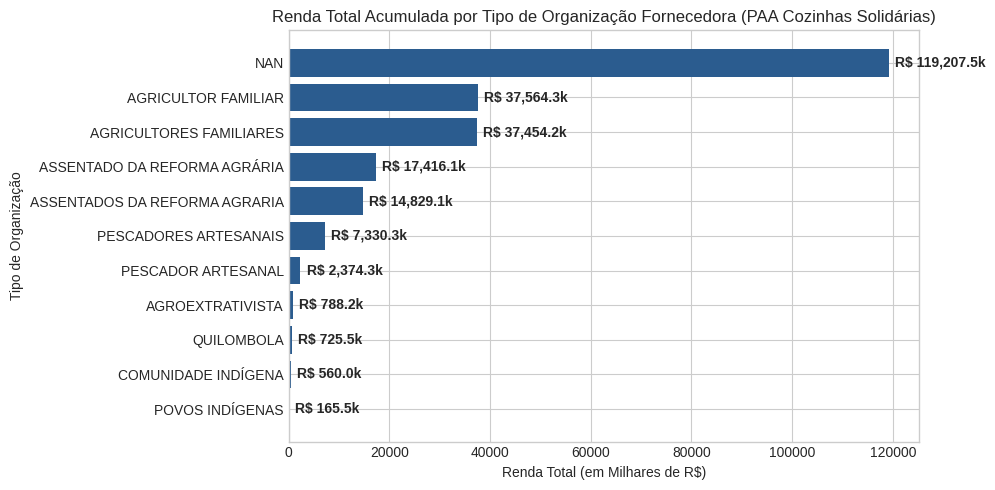

In [6]:
# Gráfico: Renda Total por Tipo de Organização
plt.figure(figsize=(10, 5))
bars = plt.barh(resumo_tipo['TIPO DE ORG'], resumo_tipo['RENDA_TOTAL'] / 1e3, color='#2b5c8f')
plt.xlabel('Renda Total (em Milhares de R$)')
plt.ylabel('Tipo de Organização')
plt.title('Renda Total Acumulada por Tipo de Organização Fornecedora (PAA Cozinhas Solidárias)')
plt.gca().invert_yaxis()

max_val = resumo_tipo['RENDA_TOTAL'].max() / 1e3
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max_val * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'R$ {width:,.1f}k', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Exportação do Resultado Final
Exporta os relatórios em formato CSV no Google Colab.

In [7]:
# Salvando as tabelas em CSV
renda_por_organizacao.to_csv('renda_por_organizacao_fornecedora.csv', index=False, encoding='utf-8-sig')
resumo_tipo.to_csv('resumo_renda_por_tipo_org.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados com sucesso:')
print('1. renda_por_organizacao_fornecedora.csv')
print('2. resumo_renda_por_tipo_org.csv')

Arquivos exportados com sucesso:
1. renda_por_organizacao_fornecedora.csv
2. resumo_renda_por_tipo_org.csv
